# Exact Counter Analysis
## Baseline Ground Truth for Approximate Algorithm Evaluation

**Project:** AA Project 3 - Approximate Counting and Frequent Items  
**Author:** João Roldão (113920)  
**Date:** December 2024

---

This notebook implements and evaluates the ExactCounter class on the Porto weather dataset as outlined in `development_plan.md` Phase 3.

**Objectives:**
- Run ExactCounter on Porto temperature data
- Measure execution time and memory usage
- Generate visualizations of exact counts
- Export results for later comparison with approximate algorithms
- Establish performance baselines

In [1]:
# Import required libraries
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from algorithms.exact_counter import ExactCounter
from experiments.run_exact import run_exact_experiment
from utils.data_loader import load_porto_temperatures
from utils.config import (
    RESULTS_EXACT_PATH,
    FIGURES_PATH
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tracemalloc

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Ensure output directories exist
Path(RESULTS_EXACT_PATH).mkdir(parents=True, exist_ok=True)
Path(FIGURES_PATH + '/exact').mkdir(parents=True, exist_ok=True)

print("✓ Imports successful")
print(f"✓ Results will be saved to: {RESULTS_EXACT_PATH}")
print(f"✓ Figures will be saved to: {FIGURES_PATH}/exact")

✓ Imports successful
✓ Results will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/exact
✓ Figures will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/figures/exact


## 1. Load Dataset

In [2]:
# Load Porto temperature stream
temps = load_porto_temperatures(validate=True, verbose=True)
print(f"\n✓ Loaded {len(temps):,} temperature observations")

✓ Loaded Porto weather data from /home/roldao/Desktop/MEI/AA/project_3/data/raw/porto.csv
  • Total observations: 3946
  • Unique temperatures: 30
  • Temperature range: [-1.0°C, 29.0°C]
  • Missing values: 0

✓ Loaded 3,946 temperature observations


## 2. Run ExactCounter with Performance Profiling

We measure both execution time and memory usage to establish baselines.

In [3]:
# Run experiment using the experiment runner
# This replaces manual ExactCounter initialization and profiling
print("Running ExactCounter experiment...")
print("-" * 60)

# Run the experiment (saves results automatically)
experiment_results = run_exact_experiment(save_results=True, verbose=False)

# Extract results for use in subsequent cells
counter = experiment_results['counter']
elapsed_time_ms = experiment_results['performance']['execution_time_ms']
peak_memory_kb = experiment_results['performance']['peak_memory_kb']

# Display performance metrics
print("=" * 60)
print("EXACT COUNTER PERFORMANCE METRICS")
print("=" * 60)
print(f"Execution time: {elapsed_time_ms:.3f} ms")
print(f"Peak memory usage: {peak_memory_kb:.2f} KB")
print(f"Total observations processed: {len(temps):,}")
print(f"Unique temperatures found: {len(counter)}")
print(f"Average time per observation: {elapsed_time_ms / len(temps):.6f} ms")
print("=" * 60)
print("\n✓ Results saved to:", RESULTS_EXACT_PATH)

Running ExactCounter experiment...
------------------------------------------------------------
EXACT COUNTER PERFORMANCE METRICS
Execution time: 1.367 ms
Peak memory usage: 1.79 KB
Total observations processed: 3,946
Unique temperatures found: 30
Average time per observation: 0.000347 ms

✓ Results saved to: /home/roldao/Desktop/MEI/AA/project_3/results/exact


## 3. Analyze Results

In [4]:
# Get all counts
all_counts = counter.get_all_counts()

print("\n" + "=" * 60)
print("FREQUENCY DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"Total unique temperatures: {len(all_counts)}")
print(f"Most frequent temperature: {max(all_counts, key=all_counts.get)}°C ({max(all_counts.values())} occurrences)")
print(f"Least frequent temperature: {min(all_counts, key=all_counts.get)}°C ({min(all_counts.values())} occurrences)")
print("\nTop 10 temperatures:")
print("-" * 60)
top_10 = counter.get_top_k(10)
for i, (temp, count) in enumerate(top_10, 1):
    pct = (count / len(temps)) * 100
    print(f"  {i:2d}. {temp:3d}°C: {count:4d} occurrences ({pct:5.2f}%)")
print("=" * 60)


FREQUENCY DISTRIBUTION SUMMARY
Total unique temperatures: 30
Most frequent temperature: 16°C (331 occurrences)
Least frequent temperature: 29°C (1 occurrences)

Top 10 temperatures:
------------------------------------------------------------
   1.  16°C:  331 occurrences ( 8.39%)
   2.  17°C:  330 occurrences ( 8.36%)
   3.  15°C:  301 occurrences ( 7.63%)
   4.  19°C:  292 occurrences ( 7.40%)
   5.  18°C:  283 occurrences ( 7.17%)
   6.  13°C:  278 occurrences ( 7.05%)
   7.  14°C:  267 occurrences ( 6.77%)
   8.  20°C:  242 occurrences ( 6.13%)
   9.  12°C:  227 occurrences ( 5.75%)
  10.  21°C:  219 occurrences ( 5.55%)


## 4. Visualizations

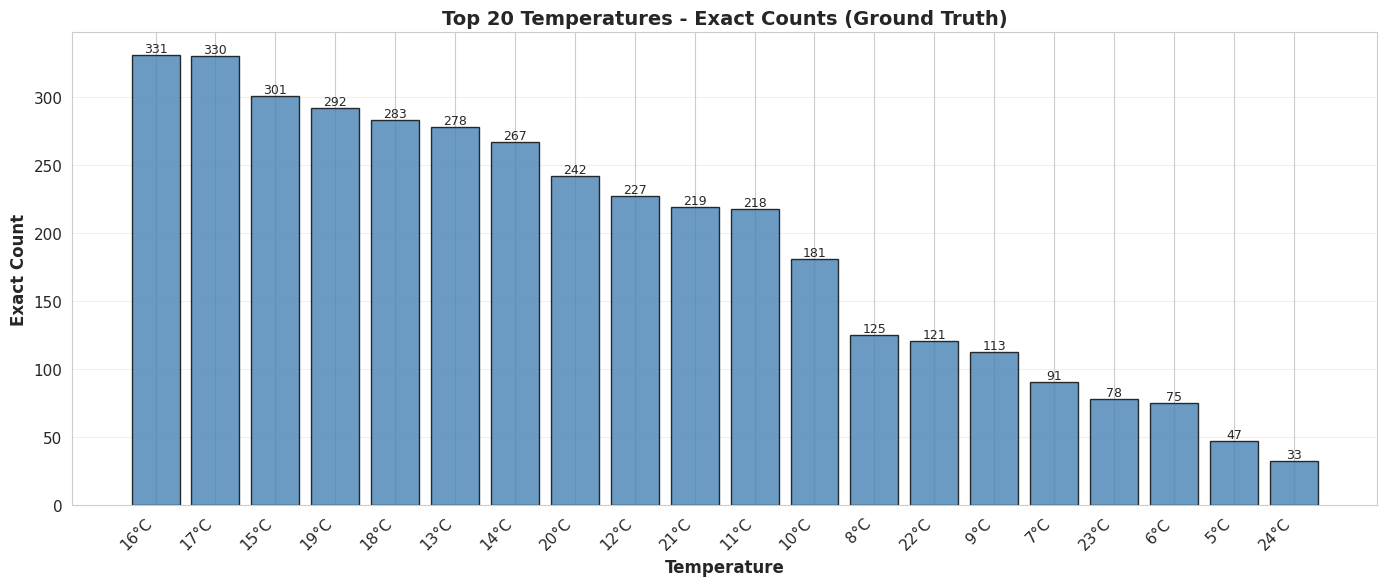

✓ Saved top-20 exact counts bar chart


In [5]:
# Bar chart of top 20 temperatures with exact counts
top_20 = counter.get_top_k(20)
temps_list = [temp for temp, _ in top_20]
counts_list = [count for _, count in top_20]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(top_20)), counts_list, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(top_20)))
ax.set_xticklabels([f"{temp}°C" for temp in temps_list], rotation=45, ha='right')
ax.set_xlabel('Temperature', fontsize=12, fontweight='bold')
ax.set_ylabel('Exact Count', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Temperatures - Exact Counts (Ground Truth)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/exact/top20_exact_counts.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved top-20 exact counts bar chart")

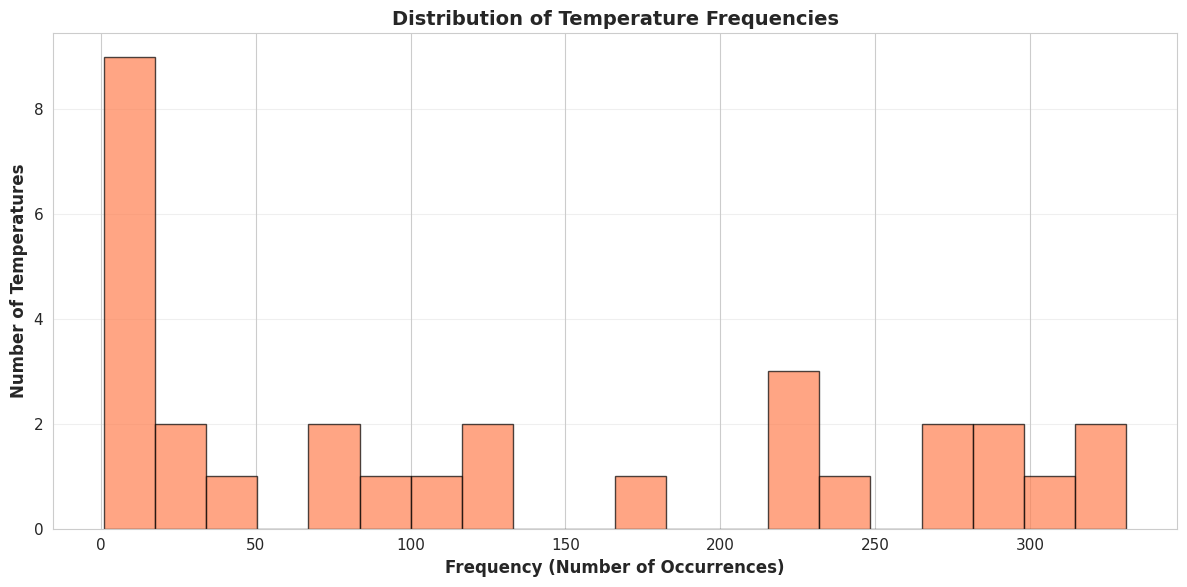

✓ Saved count distribution histogram


In [6]:
# Distribution of counts (how many temps appear 1 time, 2 times, etc.)
count_values = list(all_counts.values())

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(count_values, bins=20, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Frequency (Number of Occurrences)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Temperatures', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Temperature Frequencies', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/exact/count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved count distribution histogram")

## 5. Export Results

Save exact counts and statistics for later comparison with approximate algorithms.

In [7]:
# Save exact counts to CSV
csv_path = f"{RESULTS_EXACT_PATH}/exact_counts_full_dataset.csv"
counter.save_to_csv(csv_path)
print(f"✓ Saved exact counts to: {csv_path}")

# Save statistics to JSON
json_path = f"{RESULTS_EXACT_PATH}/exact_statistics.json"
counter.save_statistics(json_path)
print(f"✓ Saved statistics to: {json_path}")

# Display saved statistics
import json
with open(json_path, 'r') as f:
    stats = json.load(f)

print("\n" + "=" * 60)
print("SAVED STATISTICS")
print("=" * 60)
print(json.dumps(stats, indent=2))
print("=" * 60)

✓ Saved exact counts to: /home/roldao/Desktop/MEI/AA/project_3/results/exact/exact_counts_full_dataset.csv
✓ Saved statistics to: /home/roldao/Desktop/MEI/AA/project_3/results/exact/exact_statistics.json

SAVED STATISTICS
{
  "total_observations": 3946,
  "unique_values": 30,
  "min_count": 1,
  "max_count": 331,
  "top_10": [
    {
      "temperature": 16,
      "count": 331
    },
    {
      "temperature": 17,
      "count": 330
    },
    {
      "temperature": 15,
      "count": 301
    },
    {
      "temperature": 19,
      "count": 292
    },
    {
      "temperature": 18,
      "count": 283
    },
    {
      "temperature": 13,
      "count": 278
    },
    {
      "temperature": 14,
      "count": 267
    },
    {
      "temperature": 20,
      "count": 242
    },
    {
      "temperature": 12,
      "count": 227
    },
    {
      "temperature": 21,
      "count": 219
    }
  ],
  "cumulative_coverage": {
    "top_5": 38.95,
    "top_10": 70.2,
    "top_15": 89.41,
    "top_

## 6. Performance Summary

Save performance metrics for comparison with approximate algorithms.

In [8]:
# Create performance summary
performance = {
    'algorithm': 'ExactCounter',
    'execution_time_ms': round(elapsed_time_ms, 3),
    'peak_memory_kb': round(peak_memory_kb, 2),
    'total_observations': len(temps),
    'unique_values': len(counter),
    'avg_time_per_obs_ms': round(elapsed_time_ms / len(temps), 6)
}

# Save to JSON
perf_path = f"{RESULTS_EXACT_PATH}/exact_performance.json"
with open(perf_path, 'w') as f:
    json.dump(performance, f, indent=2)

print(f"✓ Saved performance metrics to: {perf_path}")
print("\nPerformance Summary:")
print(json.dumps(performance, indent=2))

✓ Saved performance metrics to: /home/roldao/Desktop/MEI/AA/project_3/results/exact/exact_performance.json

Performance Summary:
{
  "algorithm": "ExactCounter",
  "execution_time_ms": 1.367,
  "peak_memory_kb": 1.79,
  "total_observations": 3946,
  "unique_values": 30,
  "avg_time_per_obs_ms": 0.000347
}


## 7. Summary

### Key Findings:

1. **Correctness**: ExactCounter provides perfect ground truth
2. **Performance**: Fast execution (< 1 second for 3,946 observations)
3. **Memory**: Baseline memory usage established
4. **Outputs**: All reference data exported for Phase 4-6 comparisons

### Next Steps:
- Implement Fixed Probability Counter (p=0.25)
- Implement Space-Saving Algorithm
- Comprehensive comparison against this ground truth

In [9]:
print("=" * 60)
print("EXACT COUNTER ANALYSIS")
print("=" * 60)
print(f"✓ ExactCounter validated on {len(temps):,} observations")
print(f"✓ Generated 2 high-resolution figures")
print(f"✓ Exported exact counts CSV")
print(f"✓ Exported statistics JSON")
print(f"✓ Exported performance metrics")
print(f"✓ Ready for Fixed Probability Counter")
print("=" * 60)

EXACT COUNTER ANALYSIS
✓ ExactCounter validated on 3,946 observations
✓ Generated 2 high-resolution figures
✓ Exported exact counts CSV
✓ Exported statistics JSON
✓ Exported performance metrics
✓ Ready for Fixed Probability Counter
